In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import plotly.express as px


In [2]:
inc_all = pd.read_csv('data/Incident_data_combined_2009_2026.csv')
mob_all = pd.read_csv('data/Mobilisation_data_combined_2009_2026.csv')

/var/folders/ml/mylzx0q15zj5ydny113g9v_80000gn/T/ipykernel_15933/4062024549.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  inc_all = pd.read_csv('data/Incident_data_combined_2009_2026.csv')
/var/folders/ml/mylzx0q15zj5ydny113g9v_80000gn/T/ipykernel_15933/4062024549.py:2: DtypeWarning: Columns (0,13,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  mob_all = pd.read_csv('data/Mobilisation_data_combined_2009_2026.csv')


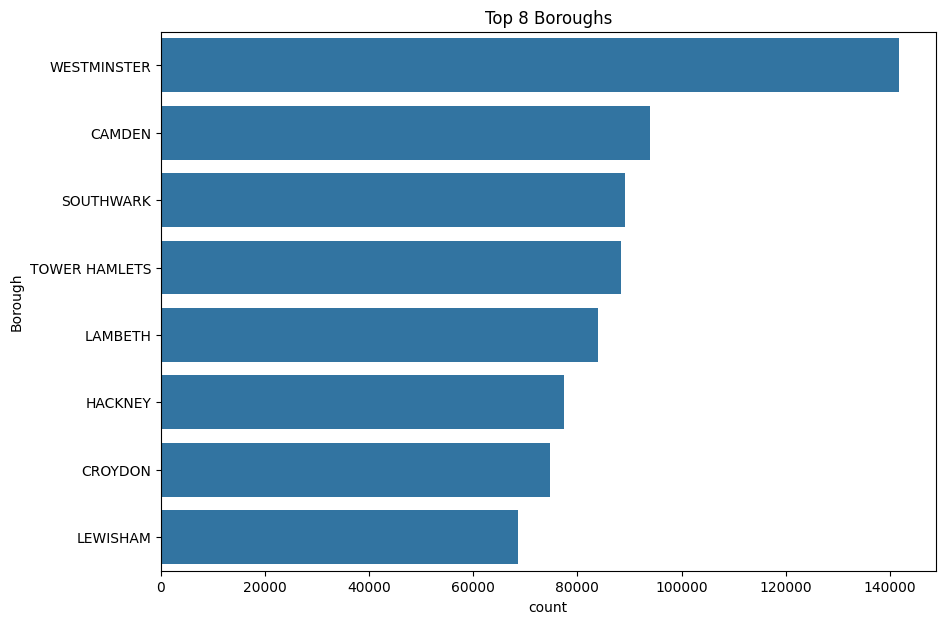

In [ ]:
#Plots 

#Plot: top 8 Boroughs

n_ = inc_all['IncGeo_BoroughName'].value_counts().head(8)

plt.figure(figsize = (10,7))
sns.barplot(x=n_.values, y=n_.index)
plt.title('Top 8 Boroughs')
plt.ylabel('Borough')
plt.xlabel('count')

#plt.savefig('Top 8 Boroughs.png', dpi=300, bbox_inches='tight') #save plot as png

plt.show()

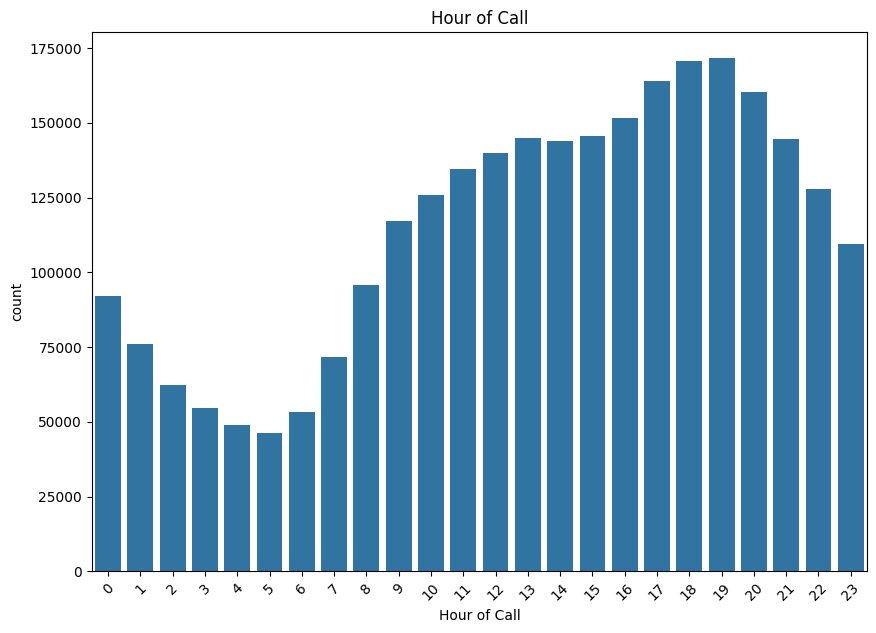

In [ ]:
#Plot: Hour of call

n_1 = mob_all['HourOfCall'].value_counts()

plt.figure(figsize = (10,7))
sns.barplot(x=n_1.index, y=n_1.values)
plt.title('Hour of Call')
plt.ylabel('count')
plt.xlabel('Hour of Call')
plt.xticks(rotation=45)

#plt.savefig('Hour of Call.png', dpi=300, bbox_inches='tight') #save plot as png

plt.show()

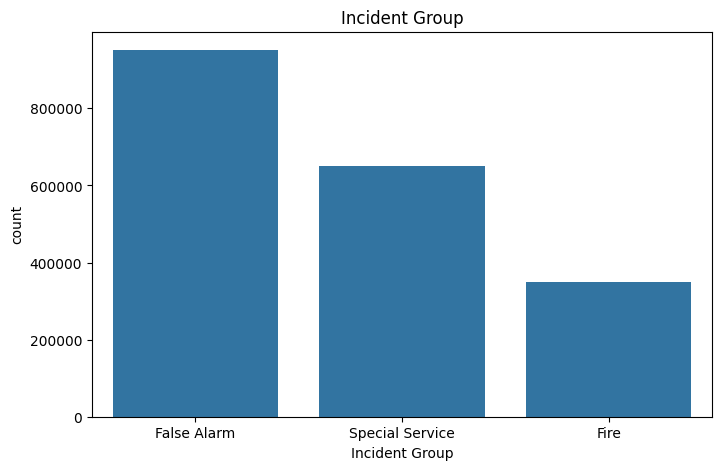

In [ ]:
#plot: incident types

n_2 = inc_all['IncidentGroup'].value_counts()

plt.figure(figsize = (8,5))
sns.barplot(x=n_2.index, y=n_2.values)
plt.title('Incident Group')
plt.ylabel('count')
plt.xlabel('Incident Group')


#plt.savefig('Incident Group.png', dpi=300, bbox_inches='tight') #save plot as png

plt.show()

/var/folders/ml/mylzx0q15zj5ydny113g9v_80000gn/T/ipykernel_15059/2765841502.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=n_pc.index, y=n_pc.values, palette='viridis')


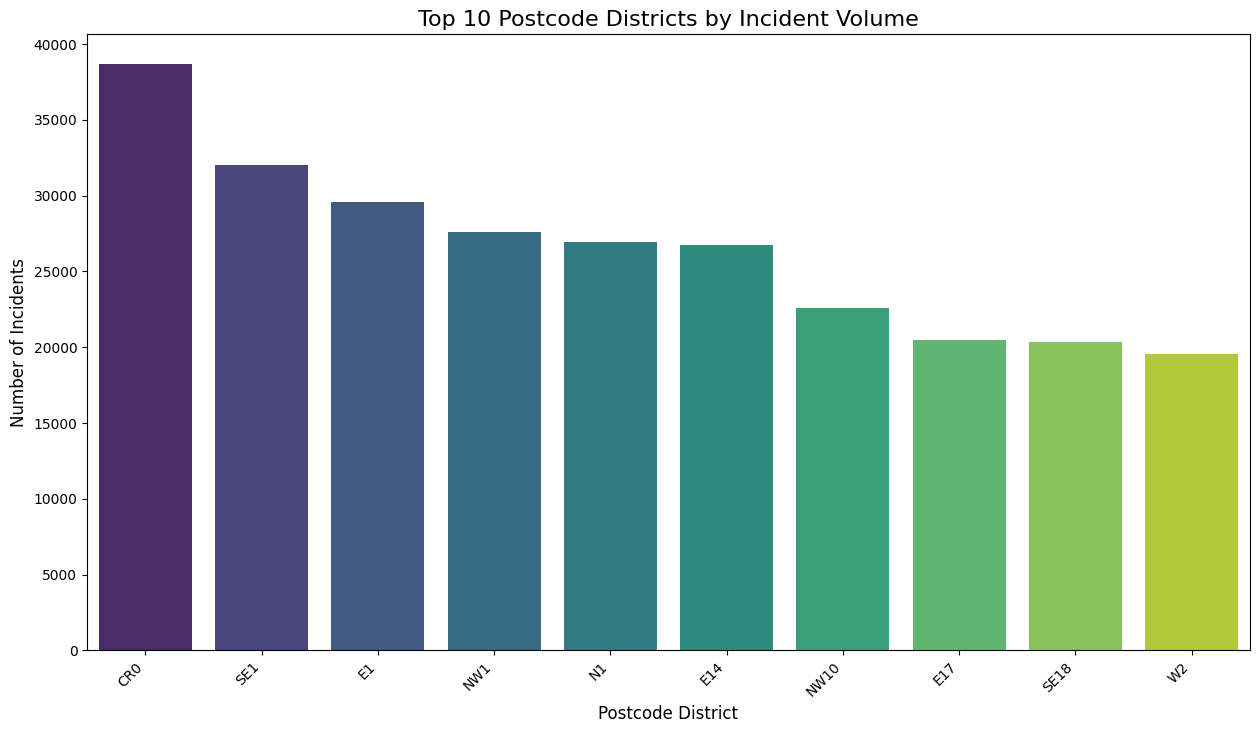

In [ ]:
n_pc = inc_all['Postcode_district'].value_counts().head(10)


plt.figure(figsize=(15, 8))
sns.barplot(x=n_pc.index, y=n_pc.values, palette='viridis')

plt.title('Top 10 Postcode Districts by Incident Volume', fontsize=16)
plt.xlabel('Postcode District', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.xticks(rotation=45, ha='right')


#plt.savefig('top_10_postcodes.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
df_map = inc_all.dropna(subset=['Latitude', 'Longitude']).sample(5000)

fig = px.scatter_mapbox(df_map, 
                        lat="Latitude", 
                        lon="Longitude", 
                        color="IncidentGroup", # Unterscheidung nach Brand, Fehlalarm etc.
                        size_max=15, 
                        zoom=10,
                        mapbox_style="carto-positron",
                        title="Incident Map London")

fig.show()


/var/folders/ml/mylzx0q15zj5ydny113g9v_80000gn/T/ipykernel_15933/1419844318.py:3: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(df_map,


/var/folders/ml/mylzx0q15zj5ydny113g9v_80000gn/T/ipykernel_15933/2670831072.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='BoroughName', y='AttendanceTimeSeconds',


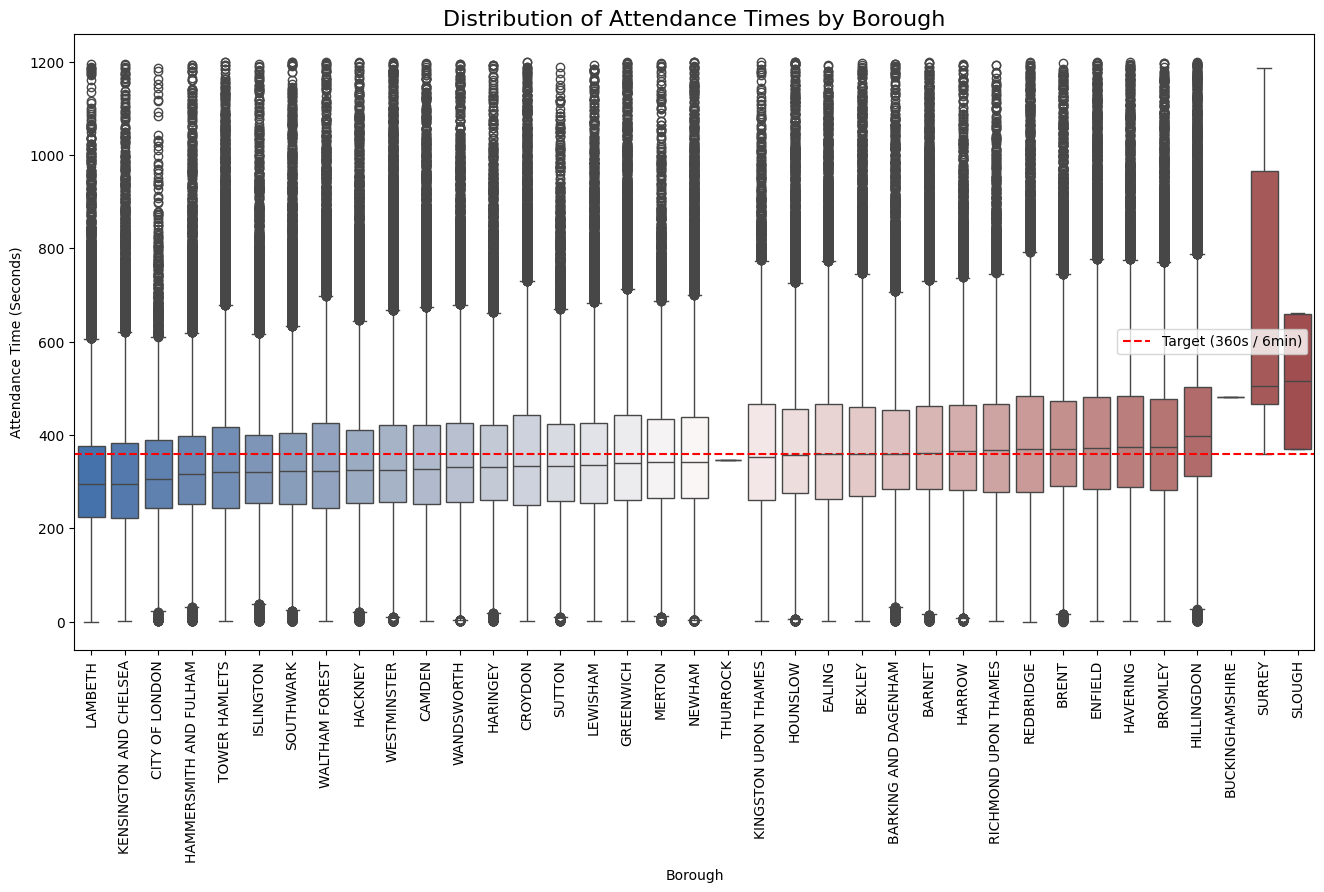

In [ ]:
# plot: attendencetime_seconds


# 1. Daten vorbereiten: Wir filtern extreme Ausreißer über 20 Min (1200s) raus, 
# damit man im Plot die Boxen noch gut erkennen kann.
df_plot = mob_all[mob_all['AttendanceTimeSeconds'] <= 1200]

# 2. Grafik erstellen
plt.figure(figsize=(16, 8))
# Wir sortieren die Boroughs nach der mittleren Ankunftszeit (Median)
order = df_plot.groupby('BoroughName')['AttendanceTimeSeconds'].median().sort_values().index

sns.boxplot(data=df_plot, x='BoroughName', y='AttendanceTimeSeconds', 
            order=order, palette='vlag')

# 3. Ziel-Linie (6 Minuten) einzeichnen
plt.axhline(360, color='red', linestyle='--', label='Target (360s / 6min)')

# 4. Styling
plt.title('Distribution of Attendance Times by Borough', fontsize=16)
plt.xticks(rotation=90) # Borough-Namen hochkant
plt.ylabel('Attendance Time (Seconds)')
plt.xlabel('Borough')
plt.legend()


#plt.savefig('boxplot_borough_performance.png', dpi=300, bbox_inches='tight')
plt.show()

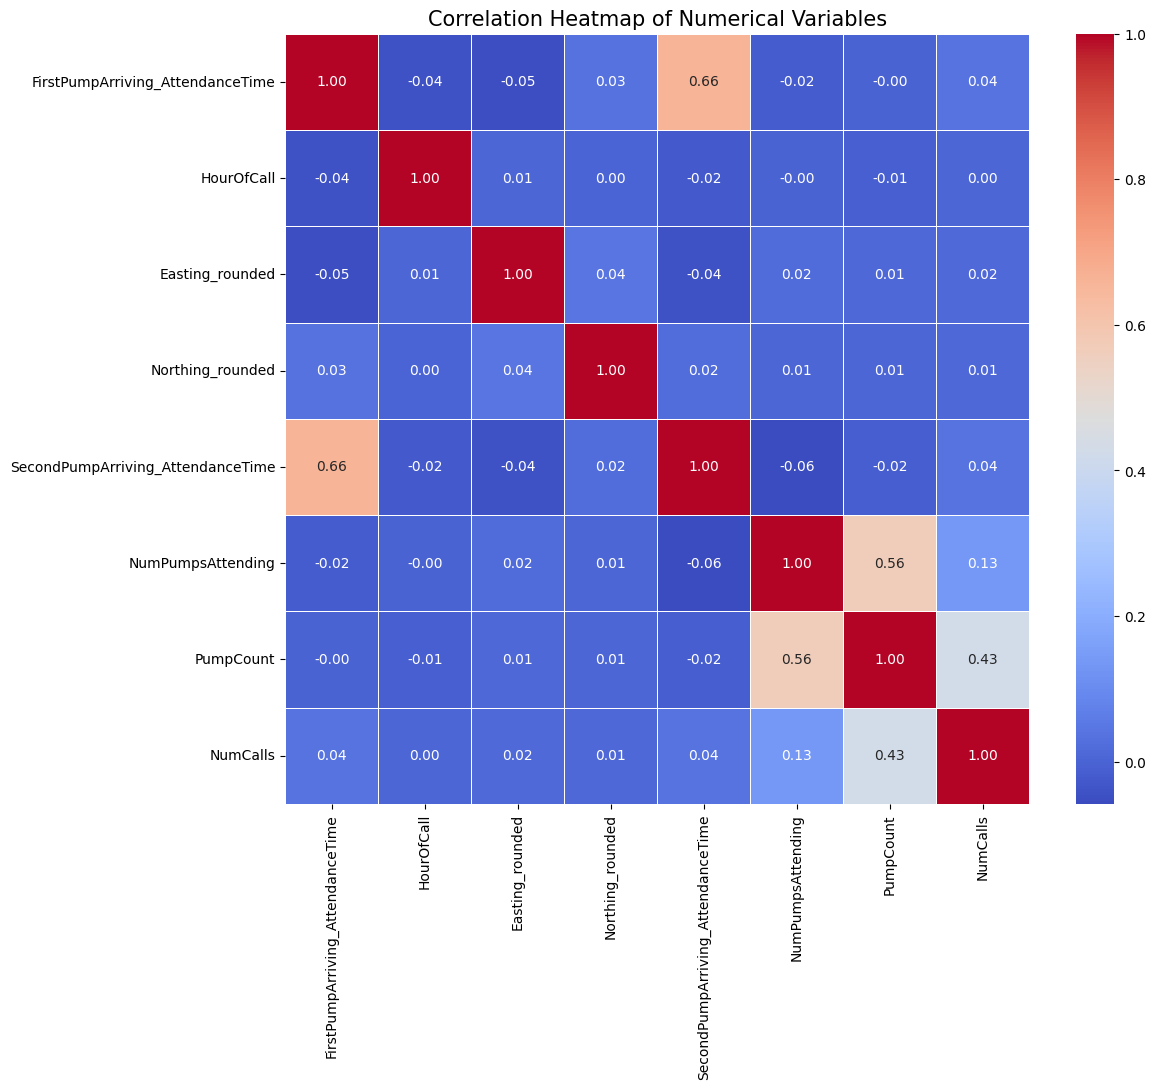

In [ ]:
# heatmap

numeric_cols = inc_all[['FirstPumpArriving_AttendanceTime', 'HourOfCall', 
                        'Easting_rounded', 'Northing_rounded', 
                        'SecondPumpArriving_AttendanceTime', 'NumPumpsAttending', 
                        'PumpCount', 'NumCalls']].dropna()

# 2. Korrelationsmatrix berechnen
corr_matrix = numeric_cols.corr()

# 3. Heatmap plotten
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap of Numerical Variables', fontsize=15)
#plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

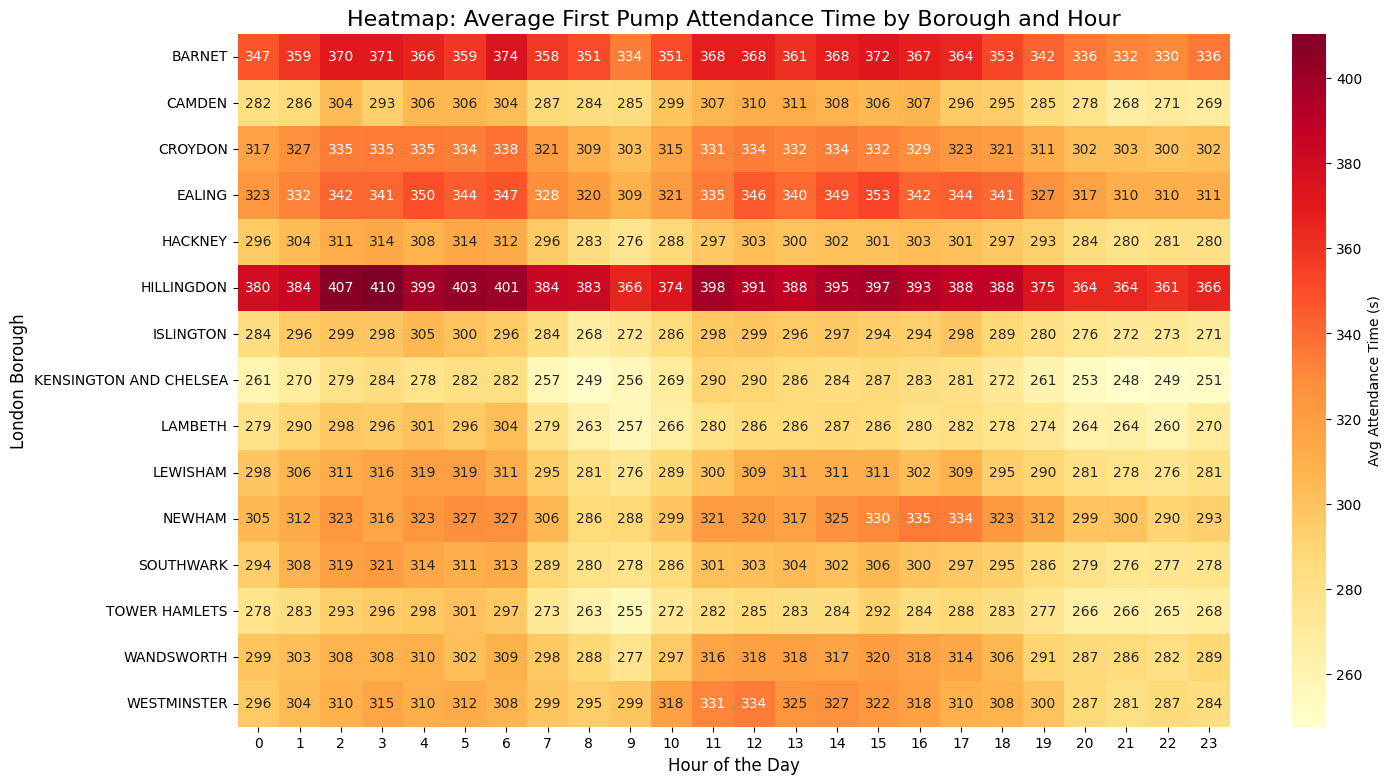

In [ ]:
#boroughName with attendence time, hour of call
top_15_boroughs = inc_all['IncGeo_BoroughName'].value_counts().head(15).index
df_top = inc_all[inc_all['IncGeo_BoroughName'].isin(top_15_boroughs)]


pivot_bg = df_top.pivot_table(index='IncGeo_BoroughName', 
                               columns='HourOfCall', 
                               values='FirstPumpArriving_AttendanceTime', 
                               aggfunc='mean')

# 3. Plotten
plt.figure(figsize=(16, 9))
sns.heatmap(pivot_bg, cmap='YlOrRd', annot=True, fmt=".0f", cbar_kws={'label': 'Avg Attendance Time (s)'})

plt.title('Heatmap: Average First Pump Attendance Time by Borough and Hour', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('London Borough', fontsize=12)


#plt.savefig('heatmap_borough_hour_performance.png', dpi=300, bbox_inches='tight')
plt.show()